# 📌 1. Importar librerías y cargar dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo gráfico profesional
sns.set(style="whitegrid", palette="dark", font_scale=1.2)

# Cargar CSV
df = pd.read_csv("SRI_Vehiculos_Nuevos_2025.csv", sep=";", encoding="latin1")

df.head(2)

,CATEGORÍA,CÓDIGO DE VEHÍCULO,TIPO TRANSACCIÓN,MARCA,MODELO,PAIS,AÑO MODELO,CLASE,SUB CLASE,TIPO,AVALUO,FECHA PROCESO (DD/MM/AAAA),TIPO SERVICIO,CILINDRAJE,TIPO COMBUSTIBLE,FECHA COMPRA (DD/MM/AAAA),CANTÓN,COLOR 1,COLOR 2,PERSONA NATURAL - JURIDICA
0,104856,10033955,COMPRA LOCAL,SCANIA,K410 CB AC 12.7 2P 4X2 TM DIESEL,BRASIL,2026,OMNIBUS,BUS,PESADO,240000,20/11/2025,PAR,12742,DIESEL,29/10/2025,21701,NEG,NaN,NATURAL
1,104844,9085740,COMPRA LOCAL,MERCEDES BENZ,OF 1723 6.4 3P 4X2 TM DIESEL,BRASIL,2024,OMNIBUS,BUS,PESADO,103192,17/9/2025,PAR,6374,DIESEL,13/8/2025,21701,AZU,AZU,NATURAL


In [2]:
import pandas as pd

# === 1. Cargar archivos ===

#df = pd.read_csv("SRI_Vehiculos_Nuevos_2025.csv", sep=";")
cantones = pd.read_excel("codigo_cantones.xlsx")
cantones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CÓDIGO_can        221 non-null    int64 
 1   DESCRIPCIÓN_can   221 non-null    object
 2   CÓDIGO_prov       221 non-null    int64 
 3   DESCRIPCIÓN_prov  221 non-null    object
dtypes: int64(2), object(2)
memory usage: 7.0+ KB


In [3]:
# === 2. Normalizar columnas clave ===

# En tu dataset: columna se llama “CANTÓN”
# En archivo de cantones: columna “CANTÓN” contiene códigos numéricos
df["CANTÓN"] = pd.to_numeric(df["CANTÓN"], errors="coerce")

# Asegurar que el archivo de cantones también esté limpio
cantones["CÓDIGO_can"] = pd.to_numeric(cantones["CÓDIGO_can"], errors="coerce")

cantones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CÓDIGO_can        221 non-null    int64 
 1   DESCRIPCIÓN_can   221 non-null    object
 2   CÓDIGO_prov       221 non-null    int64 
 3   DESCRIPCIÓN_prov  221 non-null    object
dtypes: int64(2), object(2)
memory usage: 7.0+ KB


In [4]:
# === 3. Dejar solo columnas necesarias del catálogo ===
# (Código del cantón y su nombre)
catalogo = cantones[["CÓDIGO_can", "DESCRIPCIÓN_can", "DESCRIPCIÓN_prov"]].copy()
catalogo.rename(columns={"DESCRIPCIÓN": "NOMBRE_CANTON"}, inplace=True)

In [5]:
catalogo.rename(columns={"CÓDIGO_can": "CANTÓN"}, inplace=True)

In [6]:
catalogo.head(2)

,CANTÓN,DESCRIPCIÓN_can,DESCRIPCIÓN_prov
0,20115,CAMILO PONCE ENRIQUEZ,AZUAY
1,20111,CHORDELEG,AZUAY


In [7]:
# === 4. Hacer el merge con el dataset principal ===
df = df.merge(catalogo, on="CANTÓN", how="left")

In [8]:
df.head()

,CATEGORÍA,CÓDIGO DE VEHÍCULO,TIPO TRANSACCIÓN,MARCA,MODELO,PAIS,AÑO MODELO,CLASE,SUB CLASE,TIPO,...,TIPO SERVICIO,CILINDRAJE,TIPO COMBUSTIBLE,FECHA COMPRA (DD/MM/AAAA),CANTÓN,COLOR 1,COLOR 2,PERSONA NATURAL - JURIDICA,DESCRIPCIÓN_can,DESCRIPCIÓN_prov
0,104856,10033955,COMPRA LOCAL,SCANIA,K410 CB AC 12.7 2P 4X2 TM DIESEL,BRASIL,2026,OMNIBUS,BUS,PESADO,...,PAR,12742,DIESEL,29/10/2025,21701,NEG,NaN,NATURAL,QUITO,PICHINCHA
1,104844,9085740,COMPRA LOCAL,MERCEDES BENZ,OF 1723 6.4 3P 4X2 TM DIESEL,BRASIL,2024,OMNIBUS,BUS,PESADO,...,PAR,6374,DIESEL,13/8/2025,21701,AZU,AZU,NATURAL,QUITO,PICHINCHA
2,104737,10483760,IMPORTACI?N DIRECTA,FORD,F-150 XL AC 5.0 CS 4X4 TA,ESTADOS UNIDOS,2023,CAMIONETA,CABINA SIMPLE,LIVIANO,...,PAR,5000,GASOLINA,23/12/2025,21701,PLO,NaN,NATURAL,QUITO,PICHINCHA
3,104724,10082307,COMPRA LOCAL,VOLKSWAGEN,DELIVERY 11.170 AC 3.8 2P 4X2 TM DIESEL,BRASIL,2026,CAMION,FURGON-C,PESADO,...,PAR,3800,DIESEL,18/11/2025,21701,BLA,NaN,NATURAL,QUITO,PICHINCHA
4,104706,10469618,COMPRA LOCAL,RANGER,125FY,CHINA POPULAR,2026,MOTOCICLETA,PASEO,LIVIANO,...,PAR,125,GASOLINA,21/12/2025,10709,NEG,ROS,NATURAL,PASAJE,EL ORO


In [9]:
# === 5. Verificar resultado ===
df[["CANTÓN", "DESCRIPCIÓN_can"]].head()

,CANTÓN,DESCRIPCIÓN_can
0,21701,QUITO
1,21701,QUITO
2,21701,QUITO
3,21701,QUITO
4,10709,PASAJE


# 📌 2. Limpieza inicial

In [10]:

#Eliminar columnas duplicadas por registros repetidos
df = df.drop_duplicates()

# Convertir valores numéricos (avaluo, cilindrada)
df["AVALUO"] = df["AVALUO"].astype(str).str.replace(",", ".").astype(float)
df["CILINDRAJE"] = pd.to_numeric(df["CILINDRAJE"], errors="coerce")

# Convertir fechas
df["FECHA PROCESO (DD/MM/AAAA)"] = pd.to_datetime(df["FECHA PROCESO (DD/MM/AAAA)"], format="%d/%m/%Y")
df["FECHA COMPRA (DD/MM/AAAA)"] = pd.to_datetime(df["FECHA COMPRA (DD/MM/AAAA)"], format="%d/%m/%Y")

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 436602 entries, 0 to 482753
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   CATEGORÍA                   436602 non-null  int64         
 1   CÓDIGO DE VEHÍCULO          436602 non-null  int64         
 2   TIPO TRANSACCIÓN            436602 non-null  object        
 3   MARCA                       436602 non-null  object        
 4   MODELO                      436602 non-null  object        
 5   PAIS                        436602 non-null  object        
 6   AÑO MODELO                  436602 non-null  int64         
 7   CLASE                       436602 non-null  object        
 8   SUB CLASE                   436602 non-null  object        
 9   TIPO                        436602 non-null  object        
 10  AVALUO                      436602 non-null  float64       
 11  FECHA PROCESO (DD/MM/AAAA)  436602 non-null 

# 📌 3. Top 10 marcas más vendidas

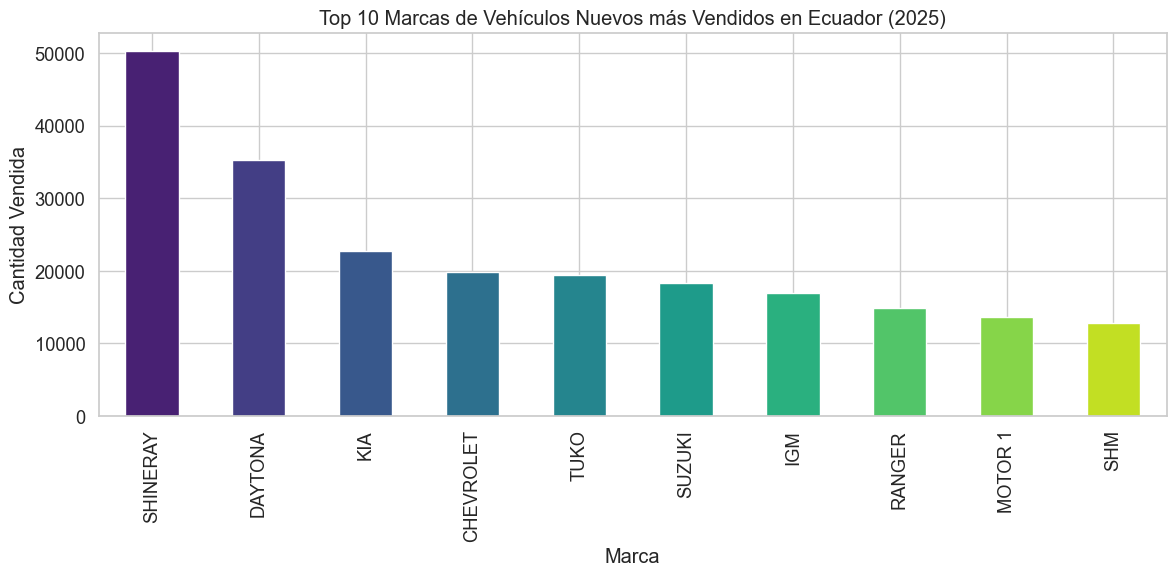

In [11]:
plt.figure(figsize=(12,6))
df["MARCA"].value_counts().head(10).plot(kind="bar", color=sns.color_palette("viridis", 10))
plt.title("Top 10 Marcas de Vehículos Nuevos más Vendidos en Ecuador (2025)")
plt.xlabel("Marca")
plt.ylabel("Cantidad Vendida")
plt.tight_layout()
plt.savefig("top10_marcas_2025.png", dpi=300)
plt.show()

# 📌 4. Distribución por tipo de vehículo

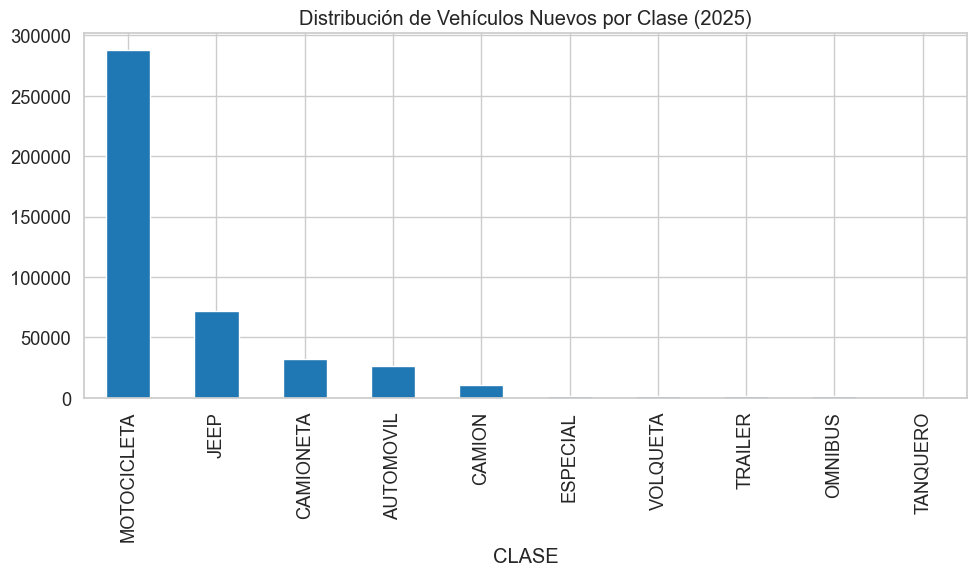

In [12]:
plt.figure(figsize=(10,6))
#df["CLASE"].value_counts().plot(kind="bar", autopct="%1.1f%%", cmap="tab20")
df["CLASE"].value_counts().head(10).plot(kind="bar", cmap="tab20")
plt.title("Distribución de Vehículos Nuevos por Clase (2025)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("clase_vehiculos_2025.png", dpi=300)
plt.show()

# 📌 5. Precio promedio por marca (avaluo)

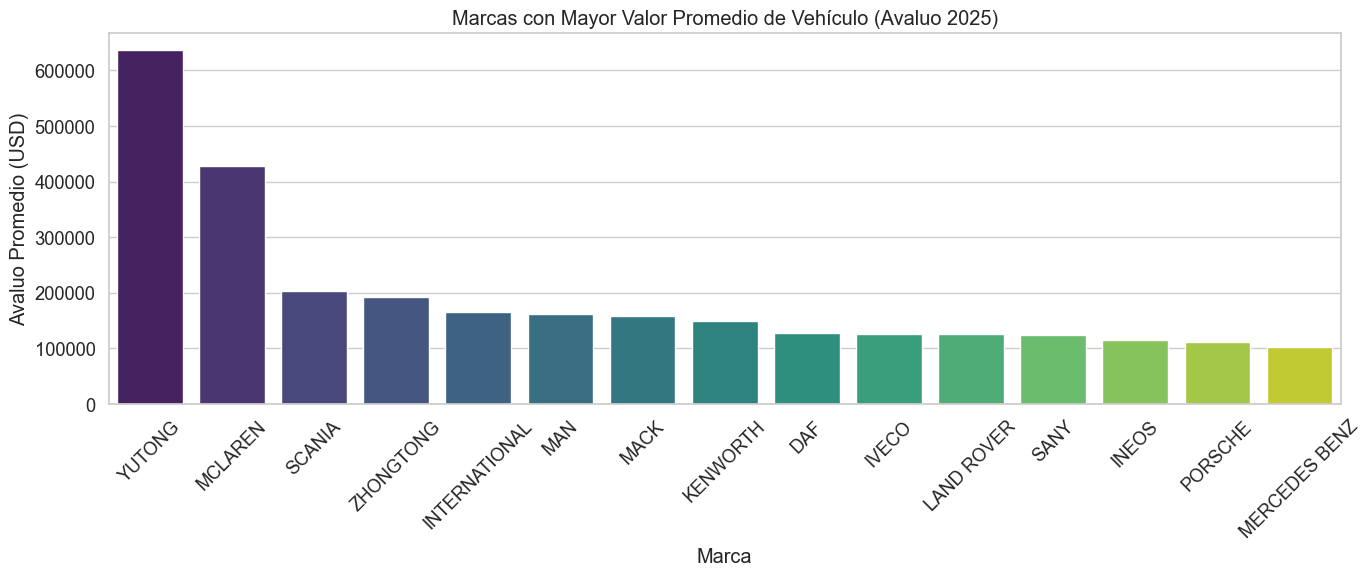

In [13]:
plt.figure(figsize=(14,6))
prom_marcas = df.groupby("MARCA")["AVALUO"].mean().sort_values(ascending=False).head(15)


sns.barplot(x=prom_marcas.index, y=prom_marcas.values, hue=prom_marcas.index, palette="viridis", legend=False)
plt.xticks(rotation=45)
plt.title("Marcas con Mayor Valor Promedio de Vehículo (Avaluo 2025)")
plt.ylabel("Avaluo Promedio (USD)")
plt.xlabel("Marca")
plt.tight_layout()
plt.savefig("avaluo_marcas_2025.png", dpi=300)
plt.show()

# 📌 6. Vehículos eléctricos e híbridos: tendencia clave para redes

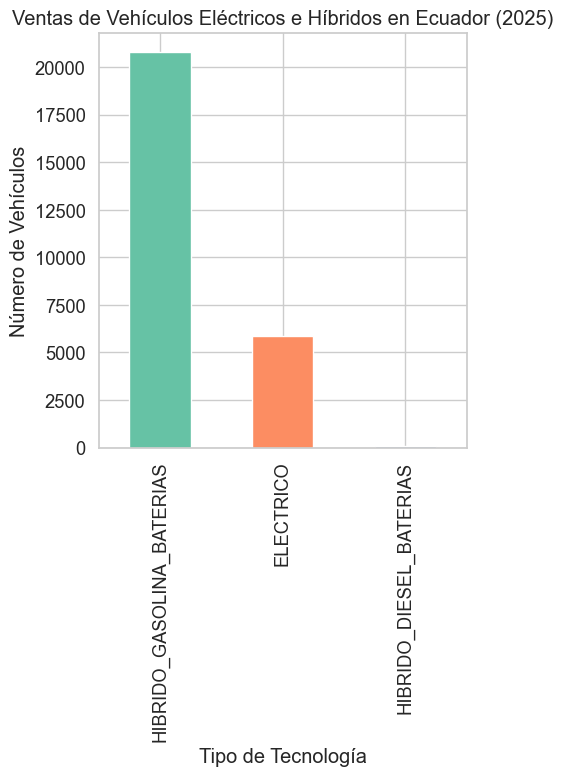

In [14]:
eco_cats = df[df["TIPO COMBUSTIBLE"].isin(["ELECTRICO", "HIBRIDO_GASOLINA_BATERIAS", "HIBRIDO_DIESEL_BATERIAS"])]

plt.figure(figsize=(5,8))
eco_cats["TIPO COMBUSTIBLE"].value_counts().plot(kind="bar", color=sns.color_palette("Set2"))
plt.title("Ventas de Vehículos Eléctricos e Híbridos en Ecuador (2025)")
plt.xlabel("Tipo de Tecnología")
plt.ylabel("Número de Vehículos")
plt.tight_layout()
plt.savefig("eco_vehiculos_2025.png", dpi=300)
plt.show()

# 📌 7. Provincias donde más se compran vehículos

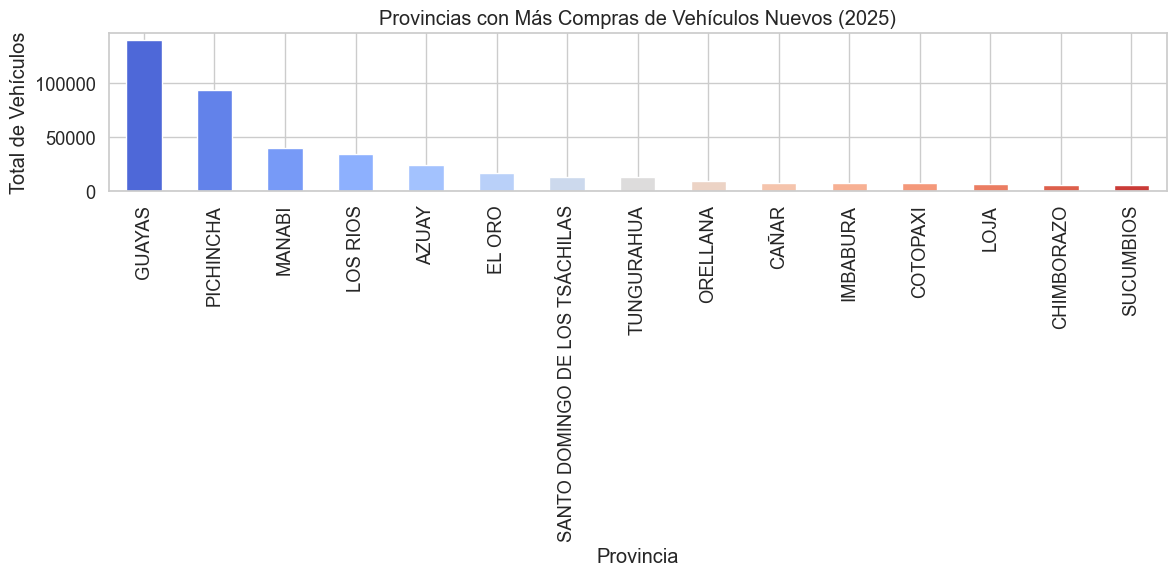

In [15]:
plt.figure(figsize=(12,6))
df["DESCRIPCIÓN_prov"].value_counts().head(15).plot(kind="bar", color=sns.color_palette("coolwarm", 15))
plt.title("Provincias con Más Compras de Vehículos Nuevos (2025)")
plt.xlabel("Provincia")
plt.ylabel("Total de Vehículos")
plt.tight_layout()
plt.savefig("provincia_vehiculos_2025.png", dpi=300)
plt.show()

# Gráficas por CANTONES

## 🔥 1) Top cantones donde más se venden vehículos

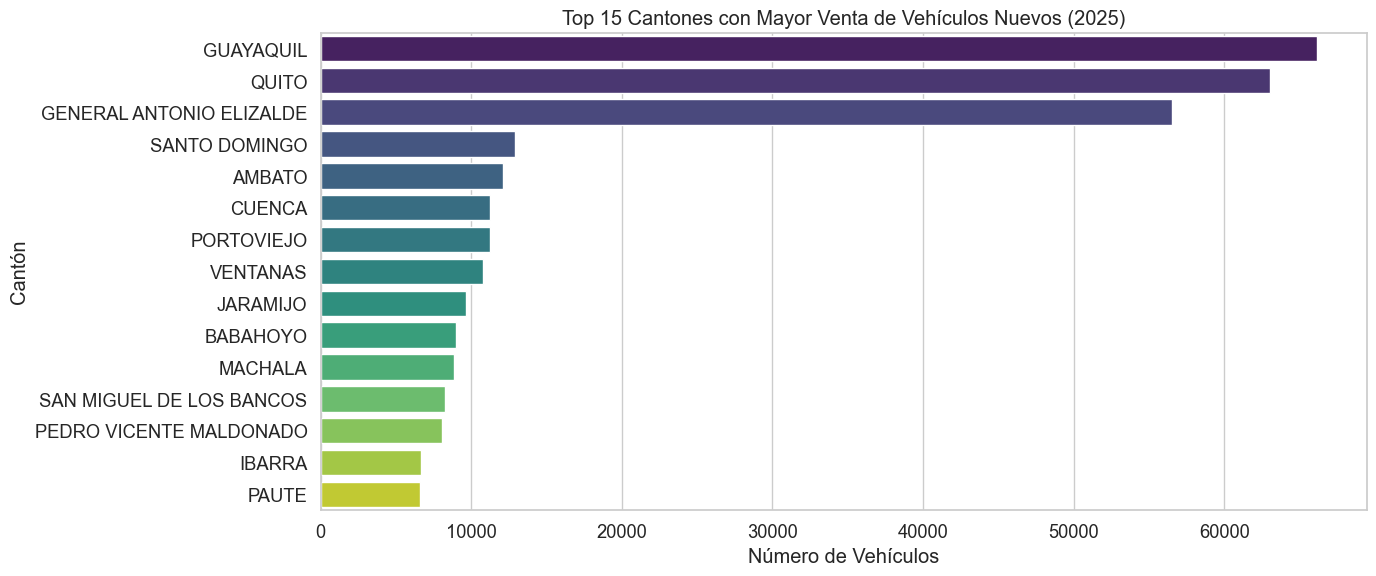

In [16]:

import matplotlib.pyplot as plt
import seaborn as sns

# Top 15 cantones con más vehículos vendidos
top_cantones = df["DESCRIPCIÓN_can"].value_counts().head(15)

plt.figure(figsize=(14,6))
sns.barplot(x=top_cantones.values, y=top_cantones.index, hue=top_cantones.index, palette="viridis", legend=False)
#sns.barplot(x=top_cantones.values, y=top_cantones.index, palette="viridis")
plt.title("Top 15 Cantones con Mayor Venta de Vehículos Nuevos (2025)")
plt.xlabel("Número de Vehículos")
plt.ylabel("Cantón")
plt.tight_layout()
plt.savefig("top_cantones_ventas_2025.png", dpi=300)
plt.show()


## Lo que revela:

1. Se identifoica en donde está realmente el mercado.
2. Cantones como Quito, Guayaquil, Cuenca, Ambato y Manta suelen liderar.
   

In [17]:
df.columns

Index(['CATEGORÍA', 'CÓDIGO DE VEHÍCULO', 'TIPO TRANSACCIÓN', 'MARCA',
       'MODELO', 'PAIS', 'AÑO MODELO', 'CLASE', 'SUB CLASE', 'TIPO', 'AVALUO',
       'FECHA PROCESO (DD/MM/AAAA)', 'TIPO SERVICIO', 'CILINDRAJE',
       'TIPO COMBUSTIBLE', 'FECHA COMPRA (DD/MM/AAAA)', 'CANTÓN', 'COLOR 1',
       'COLOR 2', 'PERSONA NATURAL - JURIDICA', 'DESCRIPCIÓN_can',
       'DESCRIPCIÓN_prov'],
      dtype='object')

## 🔥 2) Mapa de calor por provincia / cantón (heatmap geográfico NO, pero sí analítico)

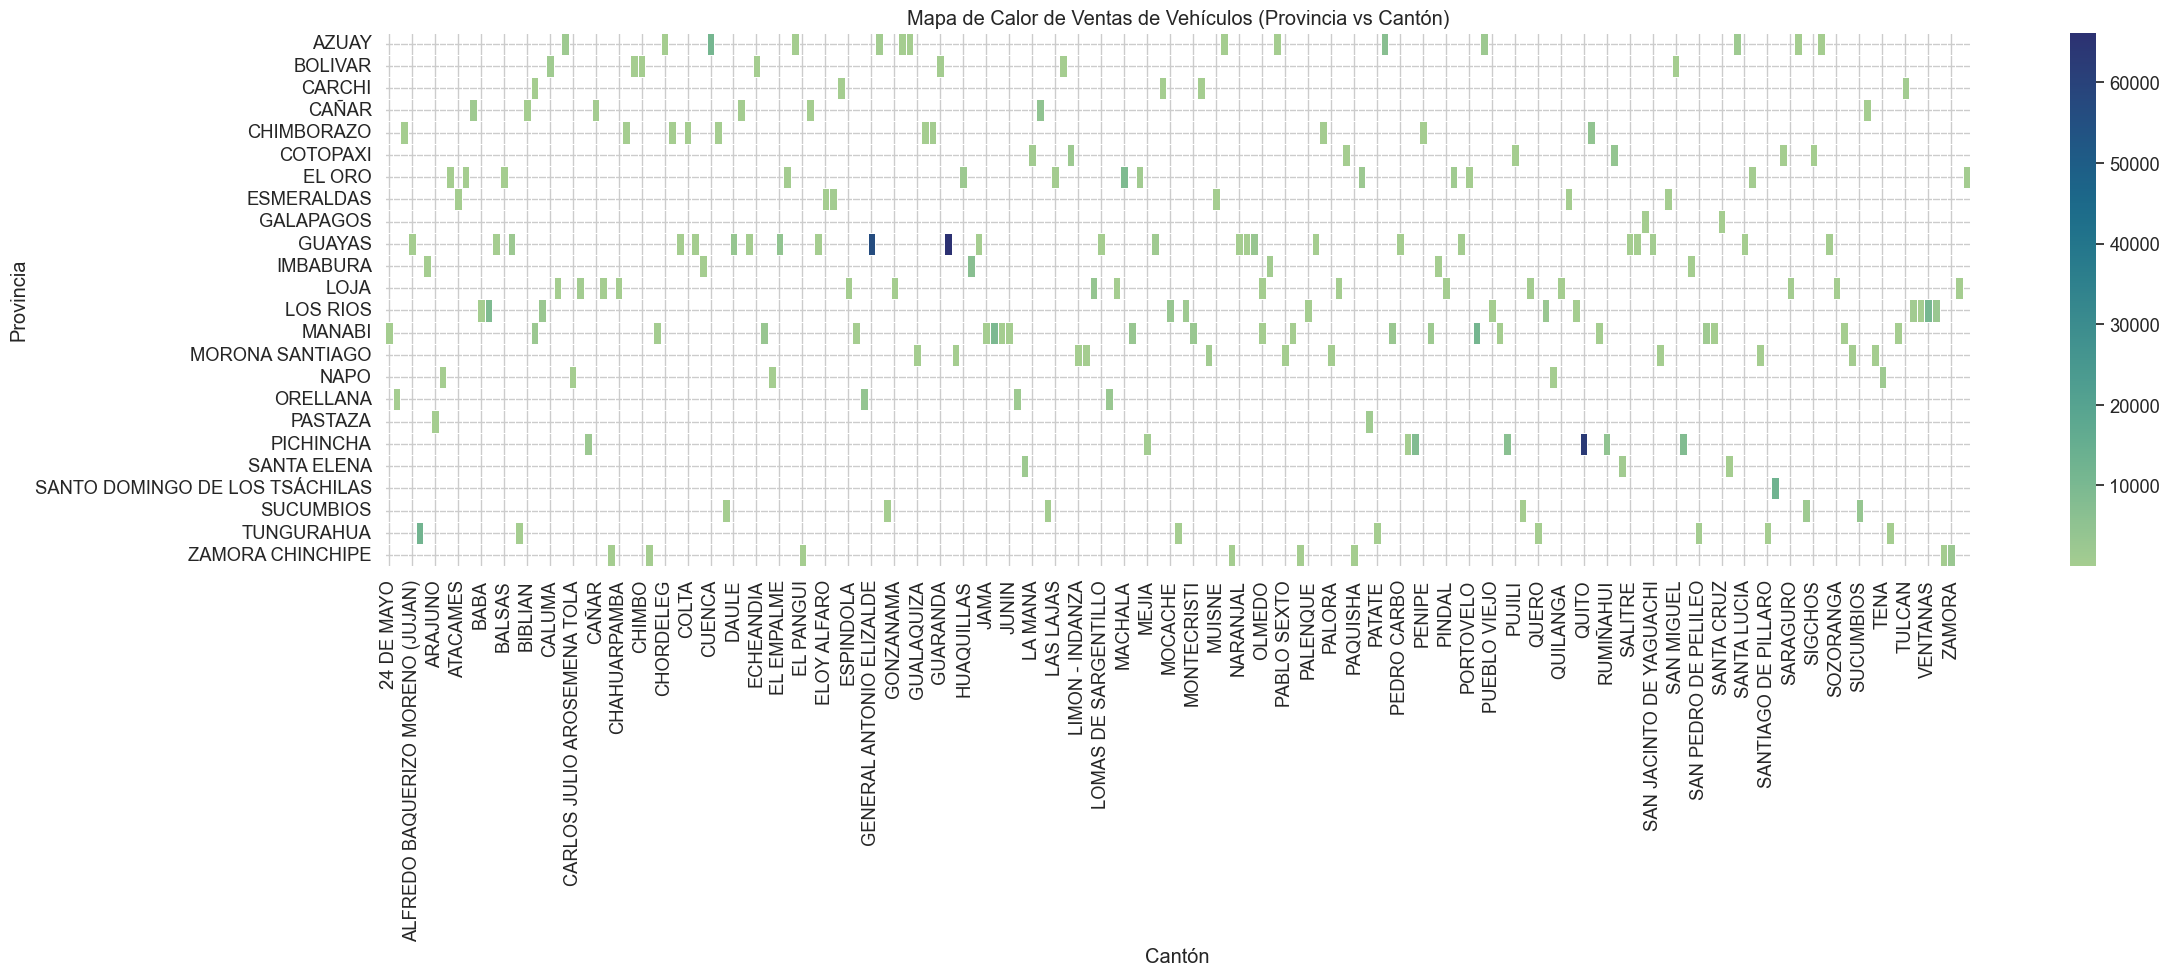

In [18]:

# Conteo de ventas por provincia y cantón
tabla_heat = df.groupby(["DESCRIPCIÓN_prov", "DESCRIPCIÓN_can"]).size().reset_index(name="VENTAS")

# Pivot para heatmap
pivot_heat = tabla_heat.pivot(index="DESCRIPCIÓN_prov", columns="DESCRIPCIÓN_can", values="VENTAS")

plt.figure(figsize=(24,10))
sns.heatmap(pivot_heat, cmap="crest", linewidths=.5)
plt.title("Mapa de Calor de Ventas de Vehículos (Provincia vs Cantón)")
plt.xlabel("Cantón")
plt.ylabel("Provincia")
plt.tight_layout()
plt.savefig("heatmap_provincia_canton_2025.png", dpi=300)
plt.show()


## 🔥 3) Distribución de vehículos por zonas del país

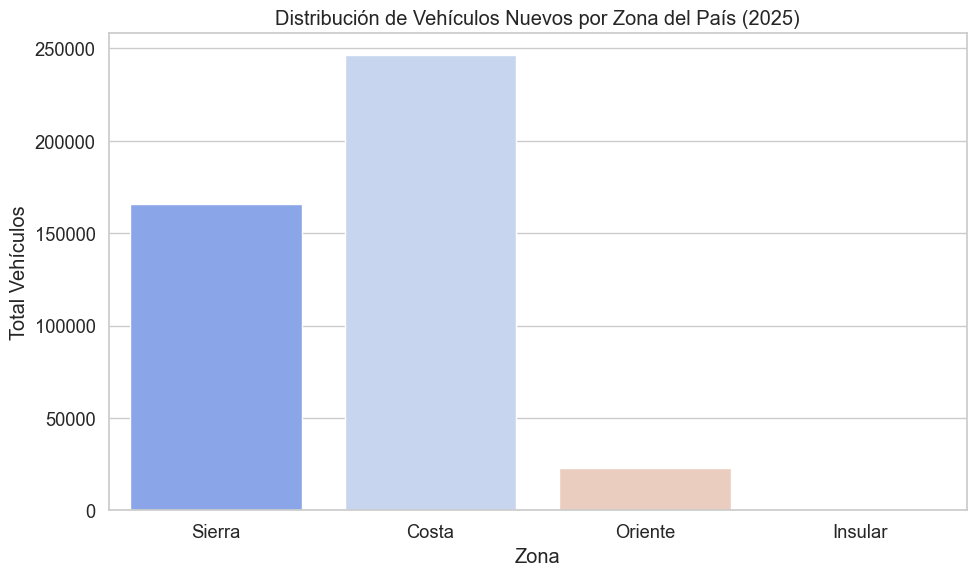

In [19]:
zona_dict = {
    # Costa
    "ESMERALDAS":"Costa", "MANABI":"Costa", "LOS RIOS":"Costa",
    "SANTO DOMINGO DE LOS TSÁCHILAS":"Costa", "GUAYAS":"Costa",
    "SANTA ELENA":"Costa", "EL ORO":"Costa",

    # Sierra
    "CARCHI":"Sierra", "IMBABURA":"Sierra", "PICHINCHA":"Sierra",
    "COTOPAXI":"Sierra", "TUNGURAHUA":"Sierra", "BOLIVAR":"Sierra",
    "CHIMBORAZO":"Sierra", "CAÑAR":"Sierra", "AZUAY":"Sierra",
    "LOJA":"Sierra",

    # Oriente
    "SUCUMBIOS":"Oriente", "ORELLANA":"Oriente", "NAPO":"Oriente",
    "PASTAZA":"Oriente", "MORONA SANTIAGO":"Oriente", "ZAMORA CHINCHIPE":"Oriente",

    # Insular
    "GALAPAGOS":"Insular"
}

# Crear la columna zona
df["ZONA"] = df["DESCRIPCIÓN_prov"].map(zona_dict)

# Gráfico de distribución
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="ZONA", hue="ZONA", palette="coolwarm", legend=False)
#sns.countplot(data=df, x="ZONA", palette="coolwarm")
plt.title("Distribución de Vehículos Nuevos por Zona del País (2025)")
plt.xlabel("Zona")
plt.ylabel("Total Vehículos")
plt.tight_layout()
plt.savefig("distribucion_zonas_2025.png", dpi=300)
plt.show()

## Lo que revela

- Muestra la importancia de la Costa en ventas.
- La Sierra también aparece fuerte por Quito–Cuenca–Ambato.
- Oriente tiene menor actividad pero en crecimiento.
- Galápagos representa un nicho interesante.

In [20]:
# 

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# 1. CARGA DE ARCHIVOS CON ENCODING CORRECTO
# ================================

df = pd.read_csv("SRI_Vehiculos_Nuevos_2025.csv", sep=";", encoding="latin-1", low_memory=False)
cantones = pd.read_excel("codigo_cantones.xlsx")

# ================================
# 2. LIMPIEZA Y NORMALIZACIÓN
# ================================

# Convertir códigos de cantón a número
# df["CANTÓN"] = pd.to_numeric(df["CANTÓN"], errors="coerce")
# cantones["CANTÓN"] = pd.to_numeric(cantones["CANTÓN"], errors="coerce")

# En archivo de cantones: columna “CANTÓN” contiene códigos numéricos
df["CANTÓN"] = pd.to_numeric(df["CANTÓN"], errors="coerce")
# Asegurar que el archivo de cantones también esté limpio
cantones["CÓDIGO_can"] = pd.to_numeric(cantones["CÓDIGO_can"], errors="coerce")

catalogo.rename(columns={"CÓDIGO_can": "CANTÓN"}, inplace=True)

# === 3. Dejar solo columnas necesarias del catálogo ===
# (Código del cantón y su nombre)
catalogo = cantones[["CÓDIGO_can", "DESCRIPCIÓN_can", "DESCRIPCIÓN_prov"]].copy()
catalogo.rename(columns={"CÓDIGO_can": "CANTÓN"}, inplace=True)
catalogo.head()
# === 4. Hacer el merge con el dataset principal ===
df = df.merge(catalogo, on="CANTÓN", how="left")

# df.head()
# # Crear catálogo cantón–nombre
# catalogo = cantones[["CANTÓN", "DESCRIPCIÓN"]].rename(columns={"DESCRIPCIÓN": "NOMBRE_CANTON"})

# # Catálogo provincia–cantón
# prov_catalog = cantones[["CANTÓN", "PROVINCIA"]].drop_duplicates()

# # Unir nombre de cantón
# df_merged = df.merge(catalogo, on="CANTÓN", how="left")

# # Unir provincia
# df_merged = df_merged.merge(prov_catalog, on="CANTÓN", how="left")

# ================================
# 3. CREAR COLUMNA DE ZONA DEL ECUADOR
# ================================

zona_dict = {
    # Costa
    "ESMERALDAS":"Costa", "MANABI":"Costa", "LOS RIOS":"Costa",
    "SANTO DOMINGO DE LOS TSÁCHILAS":"Costa", "GUAYAS":"Costa",
    "SANTA ELENA":"Costa", "EL ORO":"Costa",

    # Sierra
    "CARCHI":"Sierra", "IMBABURA":"Sierra", "PICHINCHA":"Sierra",
    "COTOPAXI":"Sierra", "TUNGURAHUA":"Sierra", "BOLIVAR":"Sierra",
    "CHIMBORAZO":"Sierra", "CAÑAR":"Sierra", "AZUAY":"Sierra",
    "LOJA":"Sierra",

    # Oriente
    "SUCUMBIOS":"Oriente", "ORELLANA":"Oriente", "NAPO":"Oriente",
    "PASTAZA":"Oriente", "MORONA SANTIAGO":"Oriente", "ZAMORA CHINCHIPE":"Oriente",

    # Insular
    "GALAPAGOS":"Insular"
}

df["ZONA"] = df["DESCRIPCIÓN_prov"].map(zona_dict)

# ================================
# 4. DASHBOARD 1 – TOP 15 CANTONES CON MÁS VENTAS
# ================================

plt.figure(figsize=(14,6))
top_cantones = df["DESCRIPCIÓN_can"].value_counts().head(15)
sns.barplot(x=top_cantones.values, y=top_cantones.index, palette="viridis")
plt.title("Top 15 Cantones con Mayor Venta de Vehículos Nuevos (2025)")
plt.xlabel("Número de Vehículos")
plt.ylabel("Cantón")
plt.tight_layout()
plt.savefig("dashboard_top_cantones.png", dpi=300)
plt.close()

# ================================
# 5. DASHBOARD 2 – HEATMAP POR PROVINCIA Y CANTÓN
# ================================

tabla_heat = df.groupby(["DESCRIPCIÓN_prov", "DESCRIPCIÓN_can"]).size().reset_index(name="VENTAS")
pivot_heat = tabla_heat.pivot(index="DESCRIPCIÓN_prov", columns="DESCRIPCIÓN_can", values="VENTAS")

plt.figure(figsize=(24,10))
sns.heatmap(pivot_heat, cmap="crest", linewidths=.5)
plt.title("Mapa de Calor de Ventas por Provincia y Cantón (2025)")
plt.xlabel("Cantón")
plt.ylabel("Provincia")
plt.tight_layout()
plt.savefig("dashboard_heatmap_ventas.png", dpi=300)
plt.close()

# ================================
# 6. DASHBOARD 3 – DISTRIBUCIÓN POR ZONA DEL PAÍS
# ================================

plt.figure(figsize=(10,6))
sns.countplot(data=df, x="ZONA", palette="coolwarm")
plt.title("Distribución de Vehículos Nuevos por Zona del País (2025)")
plt.xlabel("Zona")
plt.ylabel("Total de Vehículos")
plt.tight_layout()
plt.savefig("dashboard_zonas.png", dpi=300)
plt.close()

print("Dashboards generados exitosamente:")
print(" - dashboard_top_cantones.png")
print(" - dashboard_heatmap_ventas.png")
print(" - dashboard_zonas.png")

C:\Users\mmunoz\AppData\Local\Temp\ipykernel_39972\3993256188.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cantones.values, y=top_cantones.index, palette="viridis")
C:\Users\mmunoz\AppData\Local\Temp\ipykernel_39972\3993256188.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="ZONA", palette="coolwarm")


Dashboards generados exitosamente:
 - dashboard_top_cantones.png
 - dashboard_heatmap_ventas.png
 - dashboard_zonas.png


In [26]:
df.columns

Index(['CATEGORÍA', 'CÓDIGO DE VEHÍCULO', 'TIPO TRANSACCIÓN', 'MARCA',
       'MODELO', 'PAIS', 'AÑO MODELO', 'CLASE', 'SUB CLASE', 'TIPO', 'AVALUO',
       'FECHA PROCESO (DD/MM/AAAA)', 'TIPO SERVICIO', 'CILINDRAJE',
       'TIPO COMBUSTIBLE', 'FECHA COMPRA (DD/MM/AAAA)', 'CANTÓN', 'COLOR 1',
       'COLOR 2', 'PERSONA NATURAL - JURIDICA', 'DESCRIPCIÓN_can',
       'DESCRIPCIÓN_prov', 'ZONA'],
      dtype='object')

In [35]:
df.to_csv("vehiculos_2025_SRI.csv", index = False)